<a href="https://colab.research.google.com/github/naserhusovic-droid/DSB-Unit-03/blob/main/02%20-%20Linear%20Regression%20I/02-simple-linear-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/naserhusovic-droid/DSB-Unit-03/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Introduction to Simple Linear Regression

---

### About
An introduction to Linear Regression: what it is, how it works, and how to run a model using `scikit-learn`.

### Learning Objectives
- Describe modeling.
- Calculate mean squared error.
- State the assumptions of a linear regression model.
- Be able to interpret the coefficients of a linear regression model.
- Identify the difference between simple and multiple linear regression.
- Fit, generate predictions from, and evaluate a linear regression model in `sklearn`, and maybe in `statsmodels`.

### Notebook Guide

Part I. **Simple Linear Regression**
- Introduction to Modeling (see slides)
- Baseline Prediction
- OLS regression model in scikit-learn
- Interpreting SLR Model
- Assumptions of SLR Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Part I: Simple Linear Regression

When you have 1 predictor variable you are doing _simple linear regression_.

## The Data
Data source: [here](https://www.rdocumentation.org/packages/fpp2/versions/2.3/topics/elecdemand)

The data consist of electricity demand for Victoria, Australia every half-hour in 2014. We have three columns:

* Total electricity demand (in gigawatts)
* Whether or not it is a workday (0/1)
* Temperature (Celsius)

In [4]:
elec_df = pd.read_csv('https://raw.githubusercontent.com/naserhusovic-droid/DSB-Unit-03/refs/heads/main/data/elecdemand.csv')

In [5]:
elec_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   demand   17520 non-null  float64
 1   workday  17520 non-null  int64  
 2   temp     17520 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 410.8 KB


In [7]:
elec_df.head(10)

,demand,workday,temp
0,3.914647,0,18.2
1,3.672550,0,17.9
2,3.497539,0,17.6
3,3.339145,0,16.8
4,3.204313,0,16.3
5,3.100043,0,16.6
6,3.039468,0,16.6
7,3.012089,0,16.7
8,3.017270,0,16.2
9,3.026672,0,16.6


In [12]:
# For this exercise only, we'll limit our focus to only days in which it was at least 20 degrees Celsius (68 F)
elec_o15d_df = elec_df[elec_df["temp"] >= 15]

elec_o15d_df

,demand,workday,temp
0,3.914647,0,18.2
1,3.672550,0,17.9
2,3.497539,0,17.6
3,3.339145,0,16.8
4,3.204313,0,16.3
...,...,...,...
17515,3.724836,1,17.7
17516,3.761887,1,17.3
17517,3.809415,1,17.1
17518,4.135946,1,16.7


In [13]:
print(elec_o15d_df.shape)

(9919, 3)


<Axes: xlabel='temp', ylabel='demand'>

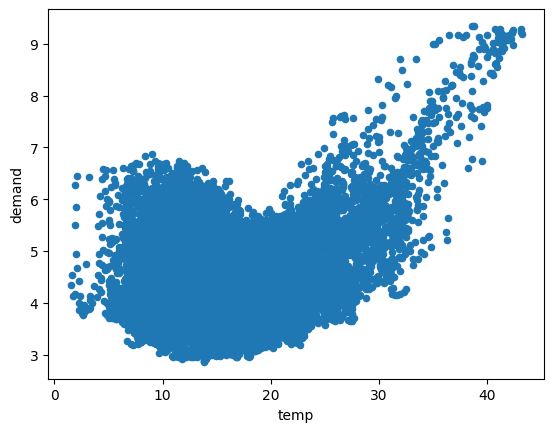

In [14]:
# Plot temperature vs. demand
elec_df.plot(kind='scatter', x='temp', y='demand')

<Axes: xlabel='temp', ylabel='demand'>

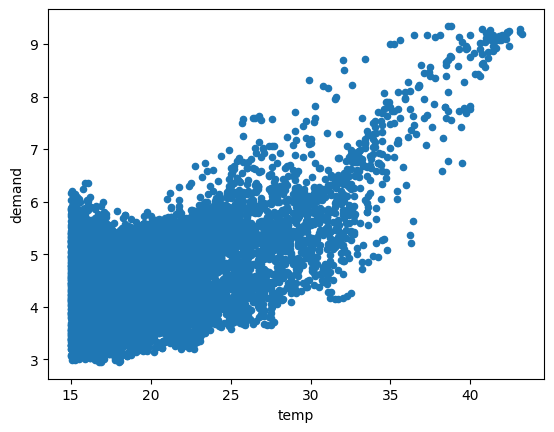

In [20]:
elec_o15d_df.plot(kind='scatter', x='temp', y='demand')

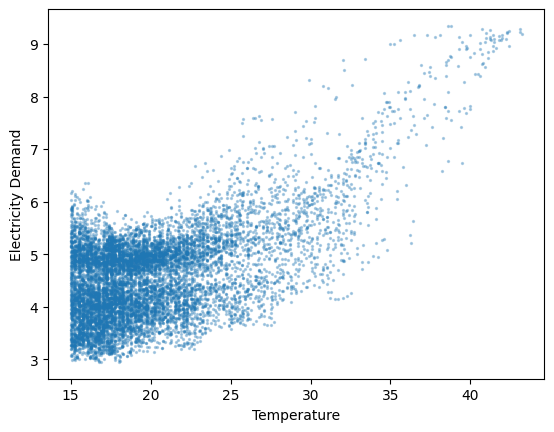

In [25]:
# using matplotlib to show the scatter plot
plt.scatter(elec_o15d_df['temp'], elec_o15d_df['demand'], s=2, alpha = 0.3)
plt.xlabel('Temperature')
plt.ylabel('Electricity Demand');


## The Null model

<details><summary>If we had to guess the demand for any new temperature what would you pick?</summary>
We don't have much information yet, so probably just the mean!
</details>

In [26]:
elec_o15d_df['demand'].mean()

np.float64(4.622494812629097)

## How could we improve our model?

<details><summary>If we were to draw a straight line that fit the points the best, what would that look like?</summary>
<img src="https://github.com/naserhusovic-droid/DSB-Unit-03/blob/main/images/ols.png?raw=1", style="height: 350px">
</details>

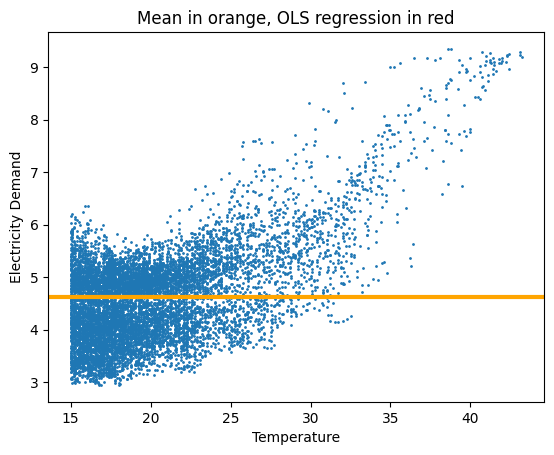

In [35]:
plt.scatter(elec_o15d_df['temp'], elec_o15d_df['demand'], s=1)
plt.axhline(elec_o15d_df['demand'].mean(), color = 'orange', lw = 3)
plt.xlabel('Temperature')
plt.ylabel('Electricity Demand')
plt.title('Mean in orange, OLS regression in red');

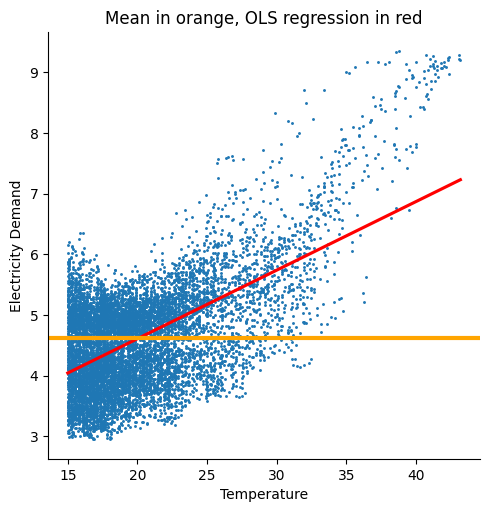

In [43]:
sns.lmplot(x='temp', y='demand', data=elec_o15d_df, ci=None,
              scatter_kws = {'s': 1, 'alpha': 0.3},
              line_kws = {'color' :'red'});

plt.scatter(elec_o15d_df['temp'], elec_o15d_df['demand'], s=1)
plt.axhline(elec_o15d_df['demand'].mean(), color = 'orange', lw = 3)
plt.xlabel('Temperature')
plt.ylabel('Electricity Demand')
plt.title('Mean in orange, OLS regression in red');

**Is that line better fit the data than our old line that was just the mean?**

Looks like it. We'll discuss formal evaluation metrics in a bit.

## Lines

This was the equation I learned for a line. Look familiar?
$$ y = mx + b$$
In data science it gets changed to

$$ y = \beta_0 + \beta_1 x_1 $$

### Errors

Our model isn't going to be perfect. The things our model doesn't capture are errors and denoted by $\epsilon$ (epsilon).

$$ y = \beta_0 + \beta_1 x_1 + \epsilon $$

### OLS Regression Modeling

We have _x_ and we have _y_. That's our data.

Our model is trying to figure out the best betas.

$$ \hat y = \hat \beta_0 + \hat \beta_1 x_1 $$


$\hat \beta_0$ is the y-intercept that our model learns. The point where the line crosses the y-axis.

$\hat \beta_1$ is the coefficient that we multiply by our $x_1$ variable. It's the slope. For every 1 unit it change in $x_1$, y increases by the value of $\beta1$.

$y$ is the ground truth of our target variable.


$$ \hat y =  \hat\beta_0 +  \hat\beta_1 x_1 $$

When we have a model that has been fit with the data the betas have been computed. We can plug in a new x value and solve for $\hat y$.

#### $\hat y$ is a prediction! 🎉

---
## OLS regression model in `scikit-learn`.

### Step 1: Assemble our predictor variables (X) and our target (y)

 We need an X matrix that is n-by-p.
- n = rows
- p = features

A feature just means a predictor column.

In the simple linear regression case, p = 1. We have one feature ($x_1$). Usually you'll have more than 1 feature.

In [44]:
# Step 1: Assemble our X and y variables

# We need an X matrix that is n-by-p (in this case, p = 1)
X = elec_o15d_df[['temp']]

In [45]:
type(X)

pandas.core.frame.DataFrame

#### Why did we make X a `DataFrame`?
`scikit-learn` expects a two dimensional object. Usually we have more than one predictor variable.

y is the outcome variable

In [46]:
# We need a y vector that is length n
y = elec_o15d_df['demand']

In [48]:
y.shape

(9919,)

#### Why is the target a `Series` or 1D numpy array?

`scikit-learn` supervised learning estimators are expecting a single output column. They predict one value for each observation, generally.

### Step 2: Instantiate the model

In [49]:
# Step 2: Instantiate the model
lr = LinearRegression()

### Step 3: Fit the model

In [50]:
# Step 3: Fit the model
lr.fit(X, y)

LinearRegression()

### Step 4: Check out and interpret our model weights

In [52]:
# Take a peek at the model coefficient and intercept
print(f'b0 is: {lr.intercept_}')
print(f' b1 is: {lr.coef_}')

b0 is: 2.3463021186002933
 b1 is: [0.11302131]


We now have the following model of reality:

$$\hat{d} = 2.32 + 0.11t$$

#### Interpretation of coefficients

In general, we can interpret our slope as having the following impact:
> For every 1 unit increase in $x_i$, we expect $y$ to increase by $\beta_i$.

<details><summary><font style = 'color:green'>How would we interpret the slope for our model?</font></summary>
For every 1 degree increase in temperature, we would expect 0.11 more gigawatts of electricty to be demanded.
</details>

#### Interpretation of our y-intercept. Does it make sense?

When it is zero degrees Celsius, we expect 2.32 gigawatts of electricity to be demanded. Ordinarily, this _would_ make sense, however, we have no data near this value (remember, we removed lots for the purpose of this exercse) and would want to avoid **extrapolation**.

### Step 5: Make predictions

If we had new data points for temperature we could pass it to the `predict` method to generate price predictions.

We don't have any new data, so let's just see what predictions our model would have made. This is the same as saying "Find the x value for a prediction on the plot and go up to our line. That value for y is our prediction."

We do this for all the x values.

In [57]:
# Make predictions
y_predict = lr.predict(X)


In [58]:
type(y_predict)

numpy.ndarray

In [59]:
list(y_predict)

[np.float64(4.403289984982949),
 np.float64(4.3693835915810375),
 np.float64(4.335477198179126),
 np.float64(4.24506014910736),
 np.float64(4.188549493437507),
 np.float64(4.222455886839419),
 np.float64(4.222455886839419),
 np.float64(4.23375801797339),
 np.float64(4.177247362303536),
 np.float64(4.222455886839419),
 np.float64(4.358081460447067),
 np.float64(4.3919878538489785),
 np.float64(4.505009165188685),
 np.float64(4.640634738796333),
 np.float64(4.595426214260449),
 np.float64(4.753656050136039),
 np.float64(4.821468836939863),
 np.float64(4.923188017145598),
 np.float64(4.991000803949422),
 np.float64(5.058813590753246),
 np.float64(5.12662637755707),
 np.float64(5.171834902092952),
 np.float64(5.284856213432659),
 np.float64(5.262251951164718),
 np.float64(5.205741295494864),
 np.float64(5.205741295494864),
 np.float64(5.024907197351334),
 np.float64(5.013605066217364),
 np.float64(4.821468836939863),
 np.float64(4.550217689724567),
 np.float64(4.482404902920743),
 np.float

In [60]:
np.set_printoptions(legacy='1.13')

In [63]:
list(lr.predict(X))

[4.4032899849829494,
 4.3693835915810375,
 4.3354771981791256,
 4.2450601491073598,
 4.1885494934375069,
 4.2224558868394189,
 4.2224558868394189,
 4.2337580179733898,
 4.177247362303536,
 4.2224558868394189,
 4.3580814604470666,
 4.3919878538489785,
 4.5050091651886852,
 4.6406347387963329,
 4.5954262142604492,
 4.7536560501360388,
 4.8214688369398626,
 4.9231880171455984,
 4.9910008039494222,
 5.0588135907532461,
 5.12662637755707,
 5.1718349020929519,
 5.2848562134326587,
 5.2622519511647177,
 5.2057412954948639,
 5.2057412954948639,
 5.0249071973513342,
 5.0136050662173641,
 4.8214688369398626,
 4.5502176897245672,
 4.4824049029207433,
 4.5389155585905963,
 4.8101667058058926,
 5.0023029350833923,
 4.9005837548776565,
 4.9118858860116275,
 4.7875624435379507,
 4.9683965416814804,
 4.8327709680738327,
 4.8666773614757446,
 4.8327709680738327,
 4.8440730992078045,
 4.8553752303417745,
 4.8440730992078045,
 4.7875624435379507,
 4.651936869930303,
 4.5728219519925091,
 4.52761342745662

#### Why don't we pass `y`?

We are predicting y.

In [65]:
elec_o15d_df['demand'].mean()

4.622494812629097

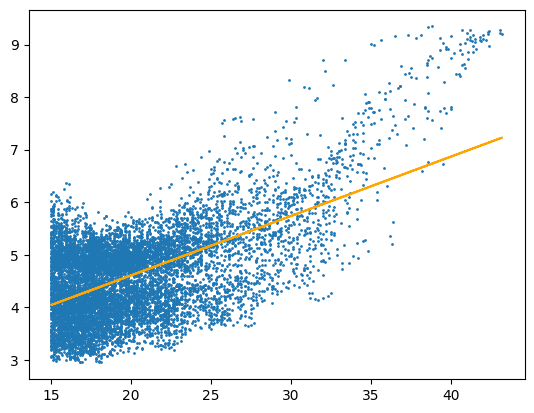

In [66]:
# We can plot them, too!
plt.scatter(elec_o15d_df['temp'], elec_o15d_df['demand'], s=1)
plt.plot(elec_o15d_df['temp'], y_predict, color='orange');

---

To the slides!

---

### Step 6: Evaluation

We now want to see how good a job our model does at predicting demand. **Mean squared error** is a popular scoring metric.

Lower is better. That's the case whenever "error" is in the metric name.

$$ MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum e_i^2 $$

#### MSE by hand:

In [68]:
# Create residuals (aka errors): (y - y_hat)
residuals = y - y_predict
residuals

,demand
0,-0.488643
1,-0.696834
2,-0.837938
3,-0.905915
4,-0.984237
...,...
17515,-0.621944
17516,-0.539684
17517,-0.469552
17518,-0.097812


In [70]:
# Compute the MSE
mse = (residuals**2).mean()
mse

0.50808927689600547

#### How does that model compare to our null model?

In [71]:
# Create the predictions for the "null model"
y_bar = y.mean()
y_bar

4.622494812629097

In [72]:
# The null MSE
null_mse = np.mean((y - y_bar)**2)
null_mse

0.77812292155379814

<details><summary>Which model fits the data better?</summary>
The OLS model has lower error.
</details>

Another popular regression metric is the $R^2$, which is defined as:

$$R^2 = 1 - \frac{\text{SSE}}{\text{Null SSE}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

The $R^2$, or **coefficient of determination**, is the proportion of variability in $y$ we can explain with $x$.

In [73]:
# The R2
1 - (mse / null_mse)

0.34703211687759417

#### Interpret $R^2$

35.2% of the variability in electricity demand can be explained by temperature.

We don't have to calculate these metrics by hand. `sklearn` can do it for us!

In [74]:
# MSE
metrics.mean_squared_error(y, y_predict)

0.5080892768960055

In [75]:
# RMSE
metrics.root_mean_squared_error(y, y_predict)

0.7128038137496218

In [76]:
# Can compute R2 from metrics...
metrics.r2_score(y, y_predict)

0.34703211687759417

In [77]:
# ... or directly from the model...
lr.score(X, y)

0.34703211687759417

### You made your first Linear Regression Model 🎉

---

To the slides!

---

## LINE Assumptions
Let's check em!

In [ ]:
# L - Linearity


<details><summary>Does this pass our L assumption?</summary>
It's definitely a little curved, but this looks okay.
</details>

In [ ]:
# I - Independence

<details><summary>Does this pass our I assumption?</summary>
Yes, by assumption.
</details>

In [ ]:
# N - Normality of errors


<details><summary>Does this pass our N assumption?</summary>
Just like with the Linearity assumption, this isn't great, but we might be able to get away with it.
</details>

In [ ]:
# E - Equal variance of errors


<details><summary>Does this pass our E assumption?</summary>
I'm gonna go with no on this one...
</details>